# 04 — Explainable AI with SHAP

Explain the strongest validation-selected classical model with SHAP. If the neural network wins the overall benchmark, the strongest classical model is used for XAI because it provides a more direct and stable SHAP analysis. Explanations describe model behaviour, not causal effects.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import shap

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import load_dataset, split_dataset
from src.explainability import build_shap_explainer, positive_class_explanation
from src.models import build_logistic_regression, build_random_forest, build_xgboost
from src.preprocessing import build_linear_preprocessor, build_tree_preprocessor

SEED = 42
rng = np.random.default_rng(SEED)
FIGURES = ROOT / 'outputs' / 'figures'
METRICS = ROOT / 'outputs' / 'metrics'
FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
selection = json.loads((METRICS / 'model_selection.json').read_text())
explainability_model_name = selection['explainability_model']
transactions = load_dataset(ROOT / 'data' / 'creditcard.csv')
X_train, X_validation, X_test, y_train, y_validation, y_test = split_dataset(transactions, random_state=SEED)
feature_names = X_train.columns.tolist()

explainability_model_name

'XGBoost'

In [3]:
if explainability_model_name == 'Logistic Regression':
    preprocessor = build_linear_preprocessor(feature_names)
    X_train_model = preprocessor.fit_transform(X_train)
    X_validation_model = preprocessor.transform(X_validation)
    model = build_logistic_regression(SEED)
    model.fit(X_train_model, y_train)
elif explainability_model_name == 'Random Forest':
    preprocessor = build_tree_preprocessor(feature_names)
    X_train_model = preprocessor.fit_transform(X_train)
    X_validation_model = preprocessor.transform(X_validation)
    model = build_random_forest(SEED)
    model.fit(X_train_model, y_train)
elif explainability_model_name == 'XGBoost':
    preprocessor = build_tree_preprocessor(feature_names)
    X_train_model = preprocessor.fit_transform(X_train)
    X_validation_model = preprocessor.transform(X_validation)
    class_counts = y_train.value_counts()
    positive_weight = float(class_counts.loc[0] / class_counts.loc[1])
    model = build_xgboost(SEED)
    model.set_params(scale_pos_weight=positive_weight)
    model.fit(X_train_model, y_train)
else:
    raise ValueError(f'Unsupported explainability model: {explainability_model_name}')

transformed_feature_names = preprocessor.get_feature_names_out().tolist()

In [4]:
background_size = min(200, len(X_train_model))
explanation_size = min(1000, len(X_validation_model))
background_indices = rng.choice(len(X_train_model), size=background_size, replace=False)
explanation_indices = rng.choice(len(X_validation_model), size=explanation_size, replace=False)
background = np.asarray(X_train_model)[background_indices]
explanation_data = np.asarray(X_validation_model)[explanation_indices]

explainer = build_shap_explainer(model, background)
explanation = positive_class_explanation(explainer(explanation_data))
explanation.feature_names = transformed_feature_names

explanation.values.shape

(1000, 30)

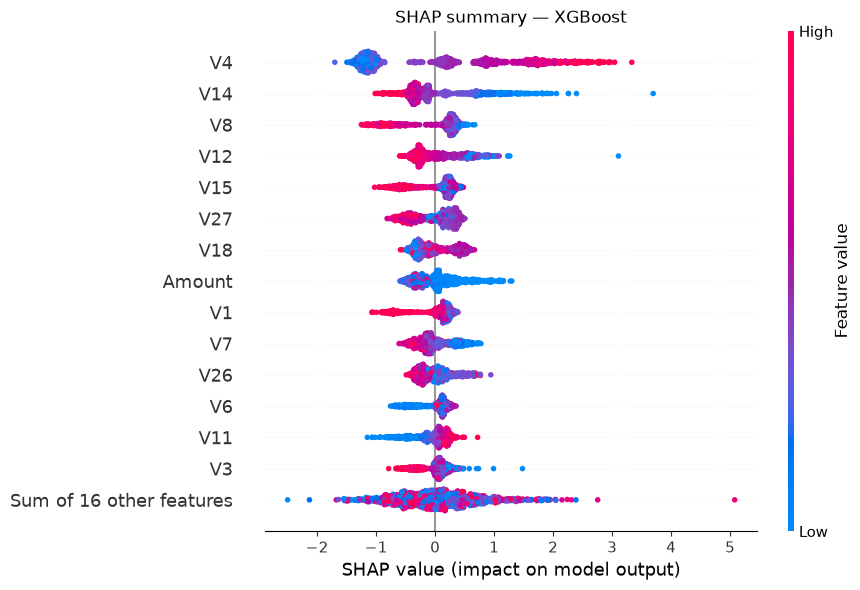

In [5]:
shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title(f'SHAP summary — {explainability_model_name}')
plt.tight_layout()
plt.savefig(FIGURES / '05_shap_summary.png', dpi=180, bbox_inches='tight')
plt.show()

In [6]:
mean_absolute_shap = np.abs(explanation.values).mean(axis=0)
ranking = sorted(zip(transformed_feature_names, mean_absolute_shap), key=lambda item: item[1], reverse=True)
top_features = [{'feature': feature, 'mean_abs_shap': float(value)} for feature, value in ranking[:15]]

with (METRICS / 'shap_feature_importance.json').open('w') as file:
    json.dump({
        'model': explainability_model_name,
        'sample_size': explanation_size,
        'interpretation': 'model contribution magnitude; not causal meaning',
        'top_features': top_features,
    }, file, indent=2)

top_features[:10]

[{'feature': 'V4', 'mean_abs_shap': 1.1469374753229995},
 {'feature': 'V14', 'mean_abs_shap': 0.47718686171455227},
 {'feature': 'V8', 'mean_abs_shap': 0.42334682416738856},
 {'feature': 'V12', 'mean_abs_shap': 0.3250024430348315},
 {'feature': 'V15', 'mean_abs_shap': 0.3148083713907129},
 {'feature': 'V27', 'mean_abs_shap': 0.30217611032295905},
 {'feature': 'V18', 'mean_abs_shap': 0.27875895501777226},
 {'feature': 'Amount', 'mean_abs_shap': 0.27204784441847607},
 {'feature': 'V1', 'mean_abs_shap': 0.2468369633216077},
 {'feature': 'V7', 'mean_abs_shap': 0.22259877842804754}]

## Interpretation limits

SHAP quantifies how features contribute to this fitted model's predictions. `V1`–`V28` are anonymized PCA components, so their rankings can be discussed as **model-important components** but cannot be translated into invented customer, merchant or behavioural meanings. The analysis is explanatory, not causal.